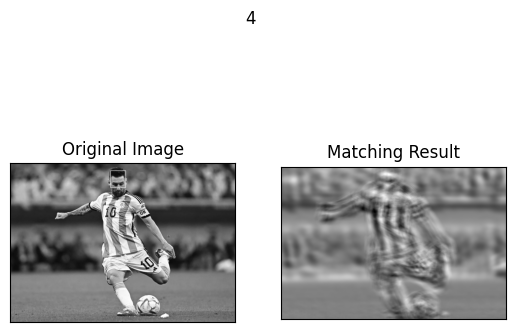

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

img = cv2.imread('messi.png', cv2.IMREAD_GRAYSCALE)
# img2 = img.copy()

template = cv2.imread('messi_face.png', cv2.IMREAD_GRAYSCALE)
w,h = template.shape[::-1]

# In total there are 6 methods for this, 
# let's at first look at only single method

method = eval('cv2.TM_CCOEFF')
res = cv2.matchTemplate(img, template, method)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res) # To find minmax location of the matching spaces

top_left = max_loc
bottom_right = (top_left[0]+w, top_left[1]+h)

cv2.rectangle(img, top_left, bottom_right, 255, 2)
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(res, cmap='gray'), plt.title('Matching Result')
plt.xticks([]), plt.yticks([])
plt.suptitle(method)
plt.show()


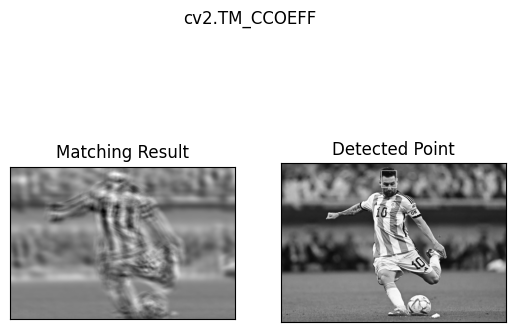

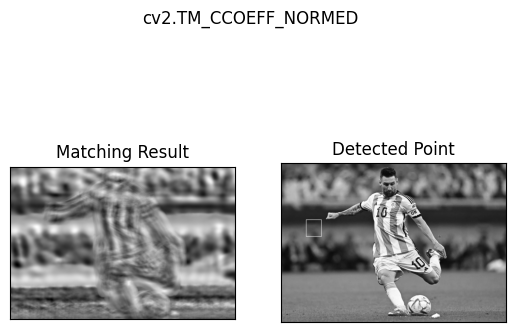

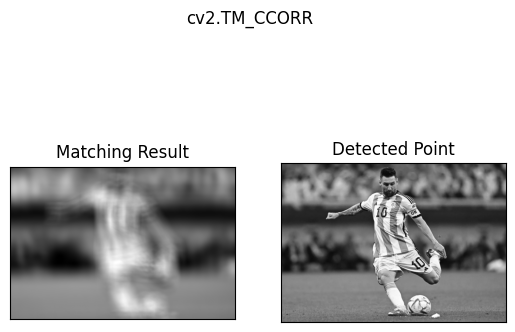

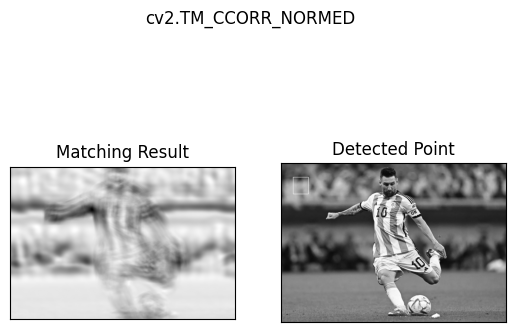

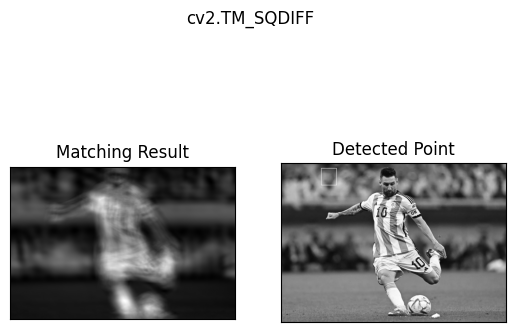

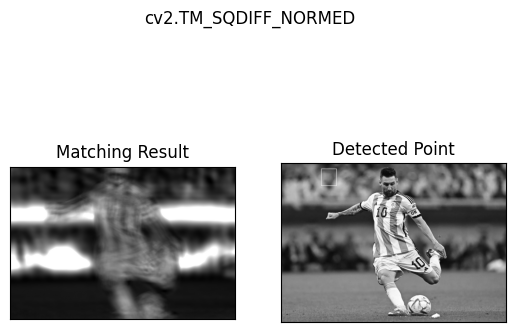

In [ ]:
# All available methods under it
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('messi.png', 0)
img2 = img.copy()
template = cv2.imread('messi_face.png', 0)
w, h = template.shape[::-1]

# All the 6 methods for comparison in a list
methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR',
           'cv2.TM_CCORR_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

for meth in methods:
    img = img2.copy()
    method = eval(meth)

    # Apply template Matching
    res = cv2.matchTemplate(img, template, method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    # If the method is TM_SQDIFF or TM_SQDIFF_NORMED, take minimum
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)

    cv2.rectangle(img, top_left, bottom_right, 255, 2)

    plt.subplot(121), plt.imshow(res, cmap='gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(img, cmap='gray')
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    plt.suptitle(meth)

    plt.show()